# Measure intensity for all channels based on coordinates from the tracked channel

In [7]:
from os import path
import pandas as pd
from IPython.display import display
import numpy as np 
import sys 
import time 
import zarr
import glob
import os
import re
import matplotlib.pyplot as plt

from scipy.spatial import cKDTree
from tqdm import tqdm
from extract_pixel_data import Extractor 

pythonPackagePath = os.path.abspath('/Users/valerie/LLSM-CME-ANALYSIS/Final/src')
sys.path.append(pythonPackagePath)

Do not change the code in the cell below

In [32]:
# Define the file directories (change these to reflect your directories)
base_dir =  r'/Volumes/ActiveNAS/Valerie/TransferFolder/'
input_file_directory = '20251204_DetectionTesting/lumenoids_analysis/'

zarr_file_directory = input_file_directory + 'zarr_file/all_channels_data'
zarr_full_path = os.path.join(base_dir, zarr_file_directory)

tracks_directory = os.path.join(base_dir, input_file_directory) + 'tracks/Channel_1_tracking_result.pkl'
detections_directory = os.path.join(base_dir, input_file_directory) + 'detections_allchannels/'

# List which channel was used for detection and tracking
channel_detected = 3

output_directory = 'datasets'
output_file_name = 'track_df_cleaned_final_full.pkl'
output_directory_full = os.path.join(base_dir, input_file_directory, output_directory, output_file_name)
print('Zarr file path:', zarr_full_path)

Zarr file path: /Volumes/ActiveNAS/Valerie/TransferFolder/20251204_DetectionTesting/lumenoids_analysis/zarr_file/all_channels_data


In [54]:
# Load the tracks and detections into new dataframe

df_tracks = pd.read_pickle(tracks_directory)
df_channel3= pd.read_pickle(os.path.join(detections_directory, 'channel_3_detections.pkl'))
df_channel2= pd.read_pickle(os.path.join(detections_directory, 'channel_2_detections.pkl'))
df_channel1= pd.read_pickle(os.path.join(detections_directory, 'channel_1_detections.pkl'))
print('Loaded tracks and detections dataframes.')

# Setting first column index to a regular column that can be called as 'frame'
df_channel3 = df_channel3.reset_index()
df_channel2 = df_channel2.reset_index()
df_channel1 = df_channel1.reset_index()

Loaded tracks and detections dataframes.


In [90]:
def find_channel_at_ap2_positions(tracks_df, channel_df, channel = 'dnm2', search_radius=2, min_consecutive=3, buffer_frames=5, frame_offset = 1, verbose=True):
    """
    Identify DNM2/ARPC3 spots near AP2 track positions using efficient spatial search.
    
    For each AP2 spot, searches for DNM2/ARPC3 detections within a cubic region of
    side length (2*search_radius + 1) voxels centered on the AP2 position.
    Example: search_radius=2 creates a 5×5×5 voxel cube.
    
    The search uses Chebyshev distance (L∞ norm):
        max(|dx|, |dy|, |dz|) ≤ search_radius
    
    This ensures the search region is exactly ±search_radius voxels in each
    dimension from the AP2 center.
    
    Track filtering:
    - Short tracks (< 6 frames) are flagged as invalid
    - Tracks starting in first buffer_frames or ending in last buffer_frames are flagged as partial
    - Tracks persisting from first buffer to last buffer are flagged as persistent
    - Only valid tracks (not short/partial/persistent) are classified as DNM2+/-
    
    Track-level classification: A valid track is considered DNM2/ARCP3-positive if it has
    at least min_consecutive consecutive frames with DNM2/ARPC3 detections IN THE SECOND
    HALF OF THE TRACK.
    
    Parameters:
    -----------
    df : pandas DataFrame
        AP2 track dataframe with columns ['mu_x', 'mu_y', 'mu_z', 'frame', 'track_id', ...]
    channel_df : pandas DataFrame
        DNM2/ARPC3 detection dataframe with columns ['mu_x', 'mu_y', 'mu_z', 'frame', ...]
    channel : str, default='dnm2'
        Channel name for labeling output columns ('dnm2' or 'arpc3')
    search_radius : int, default=2
        Search radius in voxels. Creates cube of side (2*radius + 1) voxels.
        Example: radius=2 → 5×5×5 cube (center ± 2 voxels)
    min_consecutive : int, default=3
        Minimum number of consecutive DNM2/ARPC3-positive frames required for track
        to be classified as DNM2/ARPC3-positive (must be in second half of track)
    buffer_frames : int, default=5
        Number of frames at start/end of movie to use as buffer for filtering
        incomplete tracks
    verbose : bool, default=True
        If True, show progress bars and create summary plot
        
    Returns:
    --------
    tuple of (valid_df, invalid_df, fig)
        valid_df: DataFrame with valid tracks and DNM2/ARPC3 classification
        invalid_df: DataFrame with short/partial/persistent tracks
        fig: matplotlib figure with summary statistics
    """
    
    # Create copy to avoid modifying original dataframe
    result_df = tracks_df.copy()
    
    # Initialize output columns with object dtype to accommodate both floats and strings
    result_df[f'{channel}_positive'] = False
    result_df[f'{channel}_mu_x'] = pd.Series(dtype='object')
    result_df[f'{channel}_mu_y'] = pd.Series(dtype='object')
    result_df[f'{channel}_mu_z'] = pd.Series(dtype='object')
    
    # Fill with None initially
    result_df[f'{channel}_mu_x'] = None
    result_df[f'{channel}_mu_y'] = None
    result_df[f'{channel}_mu_z'] = None
    
    # Get total number of frames in the movie
    n_frames = result_df['frame'].max()
    print(f"Total number of frames in movie: {n_frames}")
    
    # =========================================================================
    # Track filtering: Identify short, persistent, and partial tracks
    # =========================================================================
    
    short_track_ids = []
    persistent_track_ids = []
    partial_track_ids = []
    
    track_groups = result_df.groupby('track_id')
    
    for track_id, track_df in track_groups:
        track_length = len(track_df)
        track_start = track_df['frame'].min()
        track_end = track_df['frame'].max()
        
        # Skip very short tracks
        if track_length < 6:
            short_track_ids.append(track_id)
            continue
        
        # Check if track is persistent (at movie boundaries)
        if track_start <= buffer_frames and track_end > n_frames - buffer_frames:
            # print(n_frames - buffer_frames)
            persistent_track_ids.append(track_id)
            continue
        
        # Check if track is partial (insufficient buffer frames)
        at_start_boundary = (track_start <= buffer_frames)
        at_end_boundary = (track_end > n_frames - buffer_frames)
        
        if at_start_boundary or at_end_boundary:
            partial_track_ids.append(track_id)
            continue
    
    # =========================================================================
    # Frame-wise DNM2 detection (for ALL tracks)
    # =========================================================================
    
    # Group both dataframes by frame for efficient per-frame processing
    ap2_grouped = result_df.groupby('frame')
    channel_grouped = channel_df.groupby('frame')
    
    # Get set of frames present in DNM2 data for quick lookup
    channel_frames = set(channel_df['frame'].unique())
    
    # Get sorted list of frames for progress bar
    frames_to_process = sorted(ap2_grouped.groups.keys())
    
    # Process each frame independently with progress bar
    for frame_idx in tqdm(frames_to_process, desc="Processing frames", disable=not verbose):
        # print(f"Processing frame {frame_idx}")
        
        ap2_frame_df = ap2_grouped.get_group(frame_idx)

        # Calculate corresponding DNM2 frame accounting for offset
        channel_frame_idx = frame_idx - frame_offset
        
        # Skip frames with no DNM2 detections
        if channel_frame_idx not in channel_frames:
            print(f"Skipping frame {frame_idx} (no DNM2 detections)")
            continue
        
        # Get DNM2 detections for this frame
        channel_frame_df = channel_grouped.get_group(channel_frame_idx)

        # print(f"Frame {frame_idx}: AP2 frames = {ap2_frame_df['frame'].unique()}, DNM2 frames = {dnm2_frame_df['frame'].unique()}")
        
        # Extract coordinates as numpy arrays
        # ap2_coords = ap2_frame_df[['mu_x', 'mu_y', 'mu_z']].values
        ap2_frame_df_clean = ap2_frame_df.dropna(subset=['mu_z', 'mu_y', 'mu_x'])
        ap2_coords = ap2_frame_df_clean[['mu_z', 'mu_y', 'mu_x']].values
        #channel_coords = channel_frame_df[['mu_x', 'mu_y', 'mu_z']].values
        channel_frame_df_clean = channel_frame_df.dropna(subset=['mu_z', 'mu_y', 'mu_x'])
        channel_coords = channel_frame_df_clean[['mu_z', 'mu_y', 'mu_x']].values
        
        # Build KD-tree for fast spatial queries
        channel_tree = cKDTree(channel_coords)
        
        # Query for all DNM2 spots within search_radius of each AP2 spot
        neighbors_lists = channel_tree.query_ball_point(
            ap2_coords,
            r=search_radius,
            p=np.inf  # Chebyshev distance for cubic region
        )
        
        # Process each AP2 spot in this frame
        for i, (ap2_idx, neighbor_indices) in enumerate(zip(ap2_frame_df.index, neighbors_lists)):
            
            # No DNM2 spots found within search radius
            if len(neighbor_indices) == 0:
                continue
            
            # Extract the AP2 coordinates for distance calculation
            ap2_coord = ap2_coords[i]
            
            # Get coordinates of all neighboring DNM2 spots
            neighbor_coords = channel_coords[neighbor_indices]
            
            # Calculate Euclidean distances to all neighbors
            distances = np.sqrt(np.sum((neighbor_coords - ap2_coord)**2, axis=1))
            
            # Find minimum distance
            min_distance = np.min(distances)
            
            # Find all spots at minimum distance (handles ties)
            closest_mask = np.abs(distances - min_distance) < 1e-10
            closest_indices = np.where(closest_mask)[0]
            
            # Handle equidistant case (≥2 spots at same distance)
            if len(closest_indices) > 1:
                result_df.loc[ap2_idx, f'{channel}_positive'] = True
                result_df.loc[ap2_idx, f'{channel}_mu_x'] = 'two_spots'
                result_df.loc[ap2_idx, f'{channel}_mu_y'] = 'two_spots'
                result_df.loc[ap2_idx, f'{channel}_mu_z'] = 'two_spots'
            else:
                # Single closest DNM2 spot found
                closest_local_idx = closest_indices[0]
                closest_global_idx = neighbor_indices[closest_local_idx]
                
                # Retrieve coordinates from original DNM2 dataframe
                closest_channel_row = channel_frame_df.iloc[closest_global_idx]
                
                # Update result dataframe
                result_df.loc[ap2_idx, f'{channel}_positive'] = True
                result_df.loc[ap2_idx, f'{channel}_mu_x'] = closest_channel_row['mu_x']
                result_df.loc[ap2_idx, f'{channel}_mu_y'] = closest_channel_row['mu_y']
                result_df.loc[ap2_idx, f'{channel}_mu_z'] = closest_channel_row['mu_z']
    
    # =========================================================================
    # Track-level classification: Only for VALID tracks
    # DNM2+ requires ≥min_consecutive consecutive frames IN SECOND HALF
    # =========================================================================
    
    # Initialize track-level column
    result_df[f'{channel}_positive_track'] = False
    
    # Get all track IDs that should NOT be classified
    filtered_track_ids = set(short_track_ids + persistent_track_ids + partial_track_ids)
    
    # Get valid track IDs
    all_track_ids = set(result_df['track_id'].unique())
    valid_track_ids = all_track_ids - filtered_track_ids
    
    # Set to store track IDs that are DNM2-positive
    positive_track_ids = set()
    
    # Process only valid tracks
    valid_track_groups = result_df[result_df['track_id'].isin(valid_track_ids)].groupby('track_id')
    
    for track_id, track_df in tqdm(valid_track_groups, desc="Classifying tracks", disable=not verbose):
        # Sort by frame to ensure consecutive frame detection
        track_df_sorted = track_df.sort_values('frame')
        
        # Get total number of frames in this track
        track_length = len(track_df_sorted)
        
        # Calculate midpoint - second half starts here
        midpoint = track_length // 2
        
        # Get DNM2 status only for second half of track
        channel_status_second_half = track_df_sorted.iloc[midpoint:][f'{channel}_positive'].values
        
        # Find maximum consecutive run of True values in second half
        max_consecutive = 0
        current_consecutive = 0
        
        for is_positive in channel_status_second_half:
            if is_positive:
                current_consecutive += 1
                max_consecutive = max(max_consecutive, current_consecutive)
            else:
                current_consecutive = 0
        
        # Check if track meets threshold for being DNM2-positive
        if max_consecutive >= min_consecutive:
            positive_track_ids.add(track_id)
    
    # Update dnm2_positive_track column for all rows of positive tracks
    result_df.loc[result_df['track_id'].isin(positive_track_ids), f'{channel}_positive_track'] = True
    
    # =========================================================================
    # Split into valid and filtered dataframes
    # =========================================================================
    
    # Create filtered dataframe with flag column
    invalid_df = result_df[result_df['track_id'].isin(filtered_track_ids)].copy()
    
    # Add flag column
    def get_flag(track_id):
        if track_id in short_track_ids:
            return 'short'
        elif track_id in persistent_track_ids:
            return 'persistent'
        elif track_id in partial_track_ids:
            return 'partial'
        return None
    
    invalid_df['flag'] = invalid_df['track_id'].apply(get_flag)
    
    # Create valid dataframe
    valid_df = result_df[result_df['track_id'].isin(valid_track_ids)].copy()
    
    # =========================================================================
    # Create summary plot
    # =========================================================================
    
    n_total_tracks = len(all_track_ids)
    n_short = len(short_track_ids)
    n_persistent = len(persistent_track_ids)
    n_partial = len(partial_track_ids)
    n_valid = len(valid_track_ids)
    n_dnm2_positive = len(positive_track_ids)

    #print the coutns:
    print(f"Total number of tracks: {n_total_tracks}")
    print(f"Number of short tracks: {n_short}")
    print(f"Number of persistent tracks: {n_persistent}")
    print(f"Number of partial tracks: {n_partial}")
    print(f"Number of valid tracks: {n_valid}")
    print(f"Number of {channel}+ tracks: {n_dnm2_positive}")
    
    # Calculate percentages
    pct_short = 100 * n_short / n_total_tracks
    pct_persistent = 100 * n_persistent / n_total_tracks
    pct_partial = 100 * n_partial / n_total_tracks
    pct_valid = 100 * n_valid / n_total_tracks
    pct_channel_of_total = 100 * n_dnm2_positive / n_total_tracks
    pct_channel_of_valid = 100 * n_dnm2_positive / n_valid if n_valid > 0 else 0
    #print the percentages:
    print(f"Percentage of short tracks: {pct_short:.2f}%")
    print(f"Percentage of persistent tracks: {pct_persistent:.2f}%")
    print(f"Percentage of partial tracks: {pct_partial:.2f}%")
    print(f"Percentage of valid tracks: {pct_valid:.2f}%")
    print(f"Percentage of {channel}+ tracks (of total): {pct_channel_of_total:.2f}%")
    print(f"Percentage of {channel}+ tracks (of valid): {pct_channel_of_valid:.2f}%")
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))
    
    categories = ['Short', 'Persistent', 'Partial', 'Valid', f'{channel}+']
    percentages = [pct_short, pct_persistent, pct_partial, pct_valid, pct_channel_of_total]
    colors = ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#1f77b4']
    
    bars = ax.bar(categories, percentages, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # Add percentage labels on bars
    for bar, pct in zip(bars, percentages):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{pct:.1f}%',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_ylabel('Percentage of Tracks', fontsize=12, fontweight='bold')
    ax.set_title('Track Classification Summary', fontsize=14, fontweight='bold')
    ax.set_ylim(0, max(percentages) * 1.15)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    if verbose:
        plt.show()
    
    return valid_df, invalid_df, fig




Total number of frames in movie: 150


Classifying tracks: 100%|██████████| 1249/1249 [00:00<00:00, 2969.02it/s]


Total number of tracks: 3822
Number of short tracks: 2005
Number of persistent tracks: 12
Number of partial tracks: 556
Number of valid tracks: 1249
Number of dnm2+ tracks: 562
Percentage of short tracks: 52.46%
Percentage of persistent tracks: 0.31%
Percentage of partial tracks: 14.55%
Percentage of valid tracks: 32.68%
Percentage of dnm2+ tracks (of total): 14.70%
Percentage of dnm2+ tracks (of valid): 45.00%


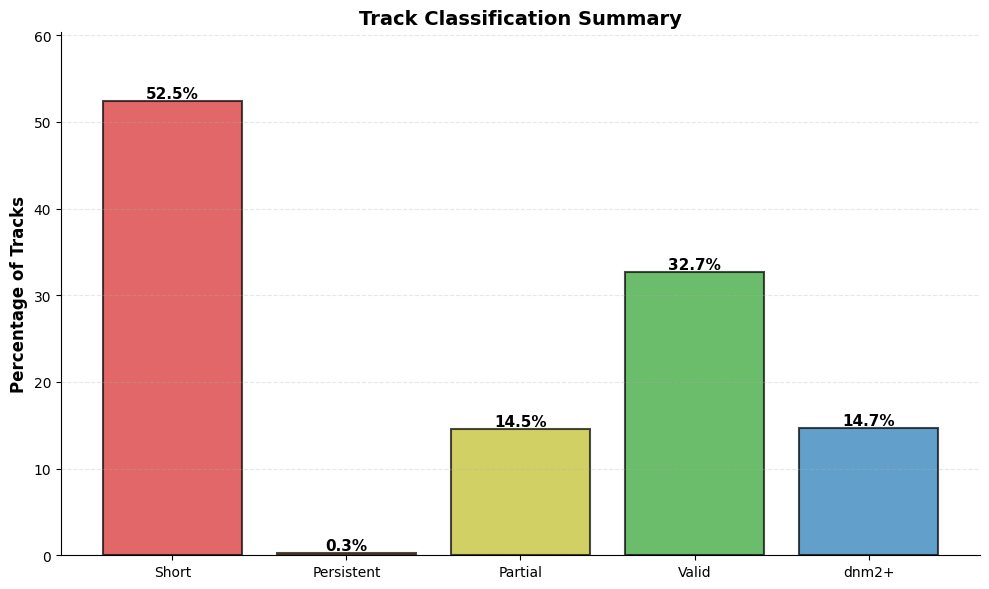

In [91]:
channel_to_use = 'dnm2' # 'dnm2' or 'arpc3'
# Example usage:
df_with_dnm2, invalid_df, fig = find_channel_at_ap2_positions(
    df_tracks, df_channel2, 
    channel = channel_to_use,
    search_radius=4, 
    min_consecutive=3, 
    buffer_frames=5, 
    frame_offset=1, # AP2 frames are 1-indexed, DNM2 are 0-indexed
    verbose=True
)

### CODE FROM BD DETECTIONS BELOW

In [3]:
track_df = pd.read_pickle(input_directory)
# read the zarr file which contains the data of all three channels 
z = zarr.open(zarr_full_path, mode='r')

# Add columns sigma_z, sigma_y, sigma_x to track_df with values 3, 2, 2
track_df['sigma_z'] = 3
track_df['sigma_y'] = 2
track_df['sigma_x'] = 2

# Dropping rows of track_df with NaN values in mu_z, mu_y, mu_x, and amplitude.
track_df_cleaned = track_df.dropna(subset=['mu_z', 'mu_y', 'mu_x', 'amplitude']).copy()
# Move frame back by 1 for track_df_cleaned, such that 1 is 0, 2 is 1, 120 is 119, etc. Don't try to set the value on a copy of a slice from a DataFrame
track_df_cleaned.loc[:, 'frame'] = track_df_cleaned['frame'] - 1
# Sorting tracks by frame, this is crucial for accuracy of the background corrected intensity measurement
track_df_cleaned = track_df_cleaned.sort_values(by=['frame']).reset_index(drop=True)

In [4]:
# Make sure that track is oragnized by frame
track_df_cleaned.head()

,frame,mu_x,mu_y,mu_z,amplitude,track_id,sigma_z,sigma_y,sigma_x
0,0,211.0,114.0,95.0,205.482965,0,3,2,2
1,0,221.0,169.0,108.0,102.046028,127,3,2,2
2,0,270.0,94.0,107.0,42.904670,128,3,2,2
3,0,150.0,99.0,49.0,69.265736,129,3,2,2
4,0,140.0,128.0,48.0,58.451489,130,3,2,2


The following parameters usually don't have to be adjusted, but you can adjust them based on the sizes of your spots


In [5]:
# radii for sum intensity ("voxel sum") calculation, in [z,y,x]. a radius of 2 will measure 5 pixels across
radii_extractor = [3,2,2] 

# the radius (in pixels) of the shell for background subtraction
# used in "_voxel_sum_adjusted" calculation
background_radius_for_voxel_sum = [1,1,1] 

# number of CPUs used for parallel processing; this isn't currently used
n_cores = -1


Optionally set an offset value in XY between channel 2 and 3

In [6]:
# If you see an offset between the cameras (channel 2 and 3), set that value here to correct for it.
# For example, if channel 2 shows up 4 pixels to the right of channel 2, set offset_x_ch2vs3 to 4

offset_x_ch2vs3 = 0
offset_y_ch2vs3 = 0

offset_ch2vs3 = [offset_y_ch2vs3, offset_x_ch2vs3]


# this line reverses the offset if you detected channel 2
if channel_detected == 2:
    offset_ch3vs2 = [-offset_ch2vs3[0], -offset_ch2vs3[1]]
else:
    offset_ch3vs2 = [0,0]
# if you don't know the offset, it will be estimated below

Calculate intensities for three channels


In [7]:
extractor = Extractor(z, dataframe = track_df_cleaned, radii=radii_extractor, frame_col_name = 'frame', 
                      radi_col_name = ['sigma_z', 'sigma_y', 'sigma_x'], n_jobs = n_cores)

channels_list = [1,2,3]

for channel in channels_list:

    offset = [0, 0]
    # need to verify that this offset works in the right direction
    if channel_detected == 2 and channel == 2:
        offset = offset_ch3vs2

    if channel_detected != 2 and channel == 2:
        offset = offset_ch2vs3

    col_names = ['mu_z', 'mu_y', 'mu_x']

    # calculate mean, max, sum intensity around the track coordinates
    peak_mean,peak_max,_,_,peak_loc,peak_sum = extractor.extract_pixels_data_fixed_bd(center_col_names = col_names, 
                                                        channel = channel, offset = offset)

    # calculate background subtracted sum intensity: "adjusted voxel sum"
    # voxel_sum_array, _, adj_voxel_sum, adj_voxel_sum_vol, vol_sig, vol_bg  = extractor.voxel_sum_fixed_background(center_col_names = ['mu_z', 'mu_y', 'mu_x'], channel = channel,                                                                            
        # background_radius=background_radius_for_voxel_sum, offset=offset)

    voxel_sum_array, _, _, adj_voxel_sum_vol, vol_sig, vol_bg  = extractor.voxel_sum_fixed_background(center_col_names = ['mu_z', 'mu_y', 'mu_x'], channel = channel,                                                                            
        background_radius=background_radius_for_voxel_sum, offset=offset)

    track_df_cleaned.loc[:,f'c{channel}_peak_mean']= peak_mean
    track_df_cleaned.loc[:,f'c{channel}_peak_max'] = peak_max
    track_df_cleaned.loc[:,f'c{channel}_voxel_sum'] = peak_sum
    # track_df_cleaned.loc[:,f'c{channel}_voxel_sum_adjusted'] = adj_voxel_sum
    track_df_cleaned.loc[:,f'c{channel}_voxel_sum_adjusted'] = adj_voxel_sum_vol
    track_df_cleaned.loc[:,f'c{channel}_peak_x'] = [t[2] for t in peak_loc]
    track_df_cleaned.loc[:,f'c{channel}_peak_y'] = [t[1] for t in peak_loc]
    track_df_cleaned.loc[:,f'c{channel}_peak_z'] = [t[0] for t in peak_loc]
    track_df_cleaned.loc[:,f'c{channel}_vol_sig'] = vol_sig
    track_df_cleaned.loc[:,f'c{channel}_vol_bg'] = vol_bg
    
    print(f'Channel {channel} done')

track_df_cleaned.to_pickle(output_directory_full)
print(f'Track intensities saved, you can continue to the next notebook.')
# track_df.head()

    


Channel 1 done
Channel 2 done
Channel 3 done
Track intensities saved, you can continue to the next notebook.


Optionally use this cell to assess offset between channel 2 and channel 3 peak intensity


In [8]:
track_df.head()



,frame,mu_x,mu_y,mu_z,amplitude,track_id,sigma_z,sigma_y,sigma_x
0,1,107.0,290.0,39.0,107.139404,0,3,2,2
1,2,108.0,290.0,39.0,97.412418,0,3,2,2
2,3,108.0,290.0,39.0,111.947919,0,3,2,2
3,4,108.0,290.0,39.0,101.603272,0,3,2,2
4,5,108.0,290.0,38.0,97.813560,0,3,2,2


Median offset between channel 2 and channel 3 in x: -1
Median offset between channel 2 and channel 3 in y: 0


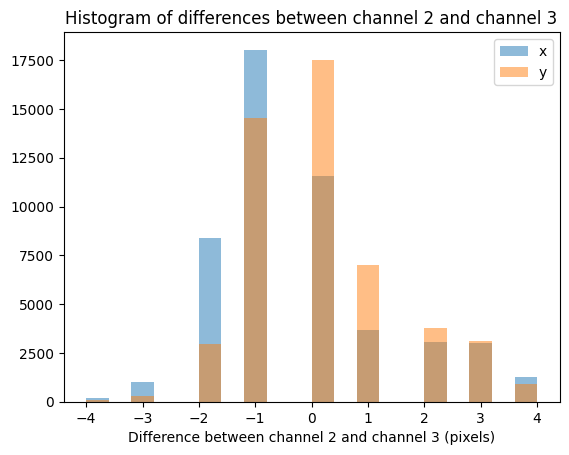

In [9]:
difs_x = track_df_cleaned['c2_peak_x'] - track_df_cleaned['c3_peak_x']
difs_x = difs_x[~np.isnan(difs_x)]
offset_x_ch2vs3 = int(difs_x.median())

difs_y = track_df_cleaned['c2_peak_y'] - track_df_cleaned['c3_peak_y']
difs_y = difs_y[~np.isnan(difs_y)]
offset_y_ch2vs3 = int(difs_y.median())

plt.hist(difs_x, bins=20, alpha=0.5)
plt.hist(difs_y, bins=20, alpha=0.5)
plt.legend(['x', 'y'])

plt.xlabel('Difference between channel 2 and channel 3 (pixels)')

plt.title('Histogram of differences between channel 2 and channel 3')

print(f'Median offset between channel 2 and channel 3 in x: {offset_x_ch2vs3}')
print(f'Median offset between channel 2 and channel 3 in y: {offset_y_ch2vs3}')


### If there is a systematic offset between the two channels, set those values in the above "set offset" cell and rerun the cells until here

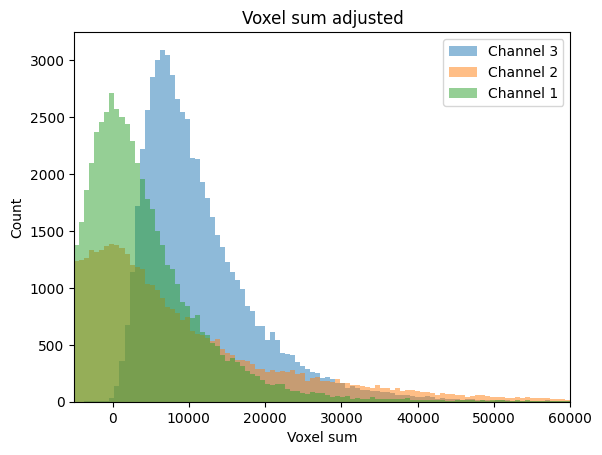

In [28]:
# plot intensity histograms for fun
# change the 'c3_voxel_sum_adjusted' value to plot other intensity metrics

# plt.hist(track_df_cleaned['c3_voxel_sum_adjusted'], bins=100, alpha=0.5, label='Channel 3')
# plt.hist(track_df_cleaned['c2_voxel_sum_adjusted'], bins=100, alpha=0.5, label='Channel 2')
# plt.hist(track_df_cleaned['c1_voxel_sum_adjusted'], bins=100, alpha=0.5, label='Channel 1')

# histogram of three channels with uniform bin sizes
plt.hist(track_df_cleaned['c3_voxel_sum_adjusted'], bins=np.linspace(-5000, 60000, 100), alpha=0.5, label='Channel 3')
plt.hist(track_df_cleaned['c2_voxel_sum_adjusted'], bins=np.linspace(-5000, 60000, 100), alpha=0.5, label='Channel 2')
plt.hist(track_df_cleaned['c1_voxel_sum_adjusted'], bins=np.linspace(-5000, 60000, 100), alpha=0.5, label='Channel 1')

plt.legend()
plt.title('Voxel sum adjusted')
plt.xlabel('Voxel sum')
plt.ylabel('Count')
plt.xlim(-5000, 60000)
plt.show()

In [34]:
# Extract information for channel 1
# track_df['c1_gaussian_amp'] = channel1_gaussians_df['amplitude']
# track_df['c1_mu_x'] = channel1_gaussians_df['mu_x']
# track_df['c1_mu_y'] = channel1_gaussians_df['mu_y']
# track_df['c1_mu_z'] = channel1_gaussians_df['mu_z']
# track_df['c1_sigma_x'] = channel1_gaussians_df['sigma_x']
# track_df['c1_sigma_y'] = channel1_gaussians_df['sigma_y']
# track_df['c1_sigma_z'] = channel1_gaussians_df['sigma_z']

# ### In the below steps dataframe is being cleaned to make column names consistent for next steps 
# ##Renaming columns to maintain data integrity 
# new_col_names = {
#     'amplitude': 'c3_gaussian_amp', 
#     'mu_x': 'c3_mu_x', 
#     'mu_y': 'c3_mu_y', 
#     'mu_z': 'c3_mu_z', 
#     'sigma_x': 'c3_sigma_x', 
#     'sigma_y': 'c3_sigma_y', 
#     'sigma_z': 'c3_sigma_z', 
#     'c2_peak': 'c2_peak_amp', 
#     'c1_peak': 'c1_peak_amp'
# }
# track_df.rename(columns=new_col_names, inplace=True)